In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.to_csv('telco_churn.csv', index=False)
print("Saved locally. Rows:", len(df))

Saved locally. Rows: 7043


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("New dtype:", df['TotalCharges'].dtype)
print("Missing values now visible:", df['TotalCharges'].isna().sum())


New dtype: float64
Missing values now visible: 11


In [5]:
missing_rows = df[df['TotalCharges'].isna()]

print("Tenure values of missing customers:", missing_rows['tenure'].unique())
print("Their monthly charges:", missing_rows['MonthlyCharges'].values)
print("Did they churn?:", missing_rows['Churn'].unique())


Tenure values of missing customers: [0]
Their monthly charges: [52.55 20.25 80.85 25.75 56.05 19.85 25.35 20.   19.7  73.35 61.9 ]
Did they churn?: <StringArray>
['No']
Length: 1, dtype: str


In [6]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Missing values remaining:", df['TotalCharges'].isna().sum())
print("Total rows kept:", len(df))
print(df.loc[df['tenure'] == 0, ['tenure', 'MonthlyCharges', 'TotalCharges']].head())

Missing values remaining: 0
Total rows kept: 7043
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           0.0
753        0           20.25           0.0
936        0           80.85           0.0
1082       0           25.75           0.0
1340       0           56.05           0.0


In [7]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


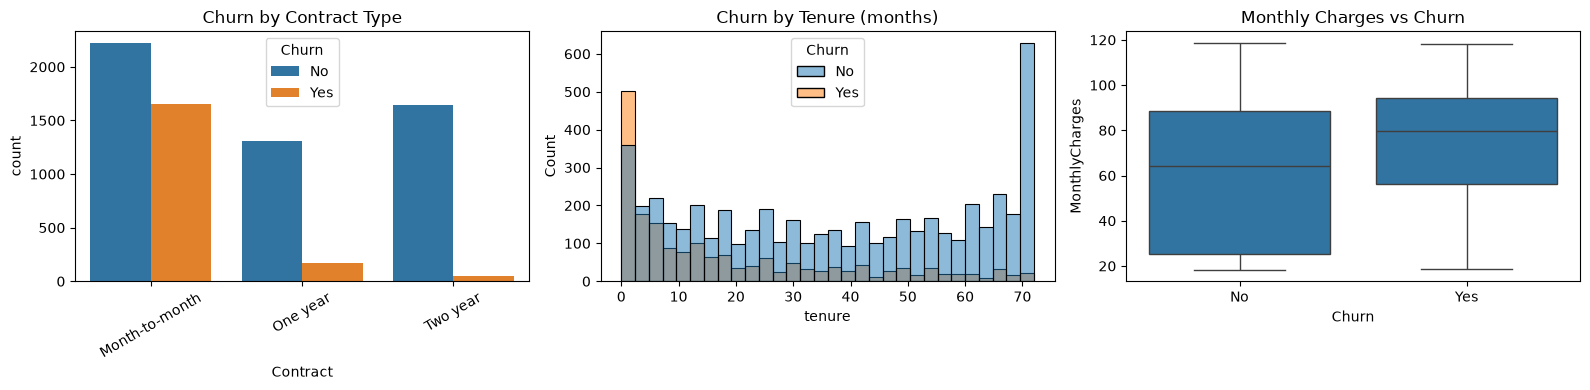

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0])
axes[0].set_title('Churn by Contract Type')
axes[0].tick_params(axis='x', rotation=30)

sns.histplot(data=df, x='tenure', hue='Churn', bins=30, ax=axes[1])
axes[1].set_title('Churn by Tenure (months)')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[2])
axes[2].set_title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

In [9]:
df_processed = df.drop('customerID', axis=1)

df_processed['Churn'] = df_processed['Churn'].map({'Yes': 1, 'No': 0})

print("Shape after dropping ID:", df_processed.shape)
print()
print(df_processed['Churn'].value_counts())

Shape after dropping ID: (7043, 20)

Churn
0    5174
1    1869
Name: count, dtype: int64


In [10]:
categorical_cols = df_processed.select_dtypes(include=['object', 'str']).columns.tolist()

print("Number of categorical columns:", len(categorical_cols))
print()

for col in categorical_cols:
    print(f"{col:20s} -> {df_processed[col].nunique()} unique: {list(df_processed[col].unique())}")

Number of categorical columns: 15

gender               -> 2 unique: ['Female', 'Male']
Partner              -> 2 unique: ['Yes', 'No']
Dependents           -> 2 unique: ['No', 'Yes']
PhoneService         -> 2 unique: ['No', 'Yes']
MultipleLines        -> 3 unique: ['No phone service', 'No', 'Yes']
InternetService      -> 3 unique: ['DSL', 'Fiber optic', 'No']
OnlineSecurity       -> 3 unique: ['No', 'Yes', 'No internet service']
OnlineBackup         -> 3 unique: ['Yes', 'No', 'No internet service']
DeviceProtection     -> 3 unique: ['No', 'Yes', 'No internet service']
TechSupport          -> 3 unique: ['No', 'Yes', 'No internet service']
StreamingTV          -> 3 unique: ['No', 'Yes', 'No internet service']
StreamingMovies      -> 3 unique: ['No', 'Yes', 'No internet service']
Contract             -> 3 unique: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling     -> 2 unique: ['Yes', 'No']
PaymentMethod        -> 4 unique: ['Electronic check', 'Mailed check', 'Bank transfer 

In [11]:
df_processed = df_processed.replace({
    'No internet service': 'No',
    'No phone service': 'No'
})

for col in ['MultipleLines', 'OnlineSecurity', 'StreamingTV']:
    print(f"{col:20s} -> {df_processed[col].nunique()} unique: {list(df_processed[col].unique())}")

print()
print("InternetService still intact:", list(df_processed['InternetService'].unique()))

MultipleLines        -> 2 unique: ['No', 'Yes']
OnlineSecurity       -> 2 unique: ['No', 'Yes']
StreamingTV          -> 2 unique: ['No', 'Yes']

InternetService still intact: ['DSL', 'Fiber optic', 'No']


In [17]:
print(X_train.shape)

(5634, 23)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logreg = LogisticRegression(max_iter=1000, random_state=42)

logreg.fit(X_train, y_train)

train_acc = accuracy_score(y_train, logreg.predict(X_train))
test_acc = accuracy_score(y_test, logreg.predict(X_test))

print("Logistic Regression")
print("Training accuracy:", round(train_acc, 4))
print("Test accuracy:", round(test_acc, 4))

Logistic Regression
Training accuracy: 0.8051
Test accuracy: 0.8055


In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf.predict(X_test))

print("Random Forest")
print("Training accuracy:", round(rf_train_acc, 4))
print("Test accuracy:", round(rf_test_acc, 4))

Random Forest
Training accuracy: 0.998
Test accuracy: 0.7899


In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

xgb.fit(X_train, y_train)

xgb_train_acc = accuracy_score(y_train, xgb.predict(X_train))
xgb_test_acc = accuracy_score(y_test, xgb.predict(X_test))

print("XGBoost")
print("Training accuracy:", round(xgb_train_acc, 4))
print("Test accuracy:", round(xgb_test_acc, 4))

XGBoost
Training accuracy: 0.9421
Test accuracy: 0.7722


In [21]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1 score:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best cross-validation F1 score: 0.5842


In [22]:
best_xgb = grid_search.best_estimator_

tuned_train_acc = accuracy_score(y_train, best_xgb.predict(X_train))
tuned_test_acc = accuracy_score(y_test, best_xgb.predict(X_test))

print("Tuned XGBoost")
print("Training accuracy:", round(tuned_train_acc, 4))
print("Test accuracy:", round(tuned_test_acc, 4))
print()
print("Reminder - untuned XGBoost was: train 0.9421, test 0.7722")
print("Reminder - Logistic Regression was: test 0.8055")

Tuned XGBoost
Training accuracy: 0.8197
Test accuracy: 0.8006

Reminder - untuned XGBoost was: train 0.9421, test 0.7722
Reminder - Logistic Regression was: test 0.8055


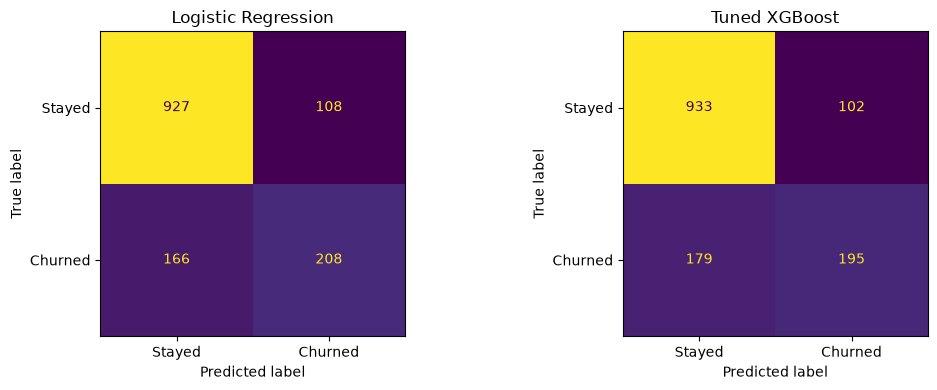

Total test customers: 1409
Actual churners in test set: 374


In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_lr = logreg.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
                       display_labels=['Stayed', 'Churned']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb),
                       display_labels=['Stayed', 'Churned']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Tuned XGBoost')

plt.tight_layout()
plt.show()

print("Total test customers:", len(y_test))
print("Actual churners in test set:", y_test.sum())

In [24]:
from sklearn.metrics import classification_report

print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_lr, target_names=['Stayed', 'Churned']))

print("=== TUNED XGBOOST ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Stayed', 'Churned']))

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

      Stayed       0.85      0.90      0.87      1035
     Churned       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

=== TUNED XGBOOST ===
              precision    recall  f1-score   support

      Stayed       0.84      0.90      0.87      1035
     Churned       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

probs = logreg.predict_proba(X_test)[:, 1]

print(f"{'Threshold':<12}{'Precision':<12}{'Recall':<12}{'F1':<12}{'Churners caught':<16}")
print("-" * 64)

for t in [0.5, 0.4, 0.35, 0.3, 0.25]:
    preds = (probs >= t).astype(int)
    p = precision_score(y_test, preds)
    r = recall_score(y_test, preds)
    f = f1_score(y_test, preds)
    caught = ((preds == 1) & (y_test == 1)).sum()
    print(f"{t:<12}{p:<12.3f}{r:<12.3f}{f:<12.3f}{caught:<16}")

print(f"\nTotal actual churners: {y_test.sum()}")

Threshold   Precision   Recall      F1          Churners caught 
----------------------------------------------------------------
0.5         0.658       0.556       0.603       208             
0.4         0.571       0.668       0.616       250             
0.35        0.545       0.703       0.614       263             
0.3         0.521       0.757       0.617       283             
0.25        0.498       0.807       0.616       302             

Total actual churners: 374
